# 03 · Exploratory analysis
Each chart answers one question. All charts are produced by `src/visualization.py` from the pipeline tables.

In [1]:
import sys, json, sqlite3
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import config
pd.set_option("display.width", 180); pd.set_option("display.max_columns", 30); pd.set_option("display.precision", 4)
T = lambda name: pd.read_csv(config.TABLES_DIR / f"{name}.csv")
KM = json.loads((config.TABLES_DIR / "key_metrics.json").read_text())
con = sqlite3.connect(config.DB_PATH)
def show(fig_name, width=11):
    img = plt.imread(config.FIGURES_DIR / f"{fig_name}.png")
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(width, width * h / w)); ax.imshow(img); ax.axis("off")
print("outputs loaded from", config.TABLES_DIR.relative_to(ROOT))

outputs loaded from outputs/tables


**Q1. How does activity evolve over the simulation, and where are the calibration and test periods?**

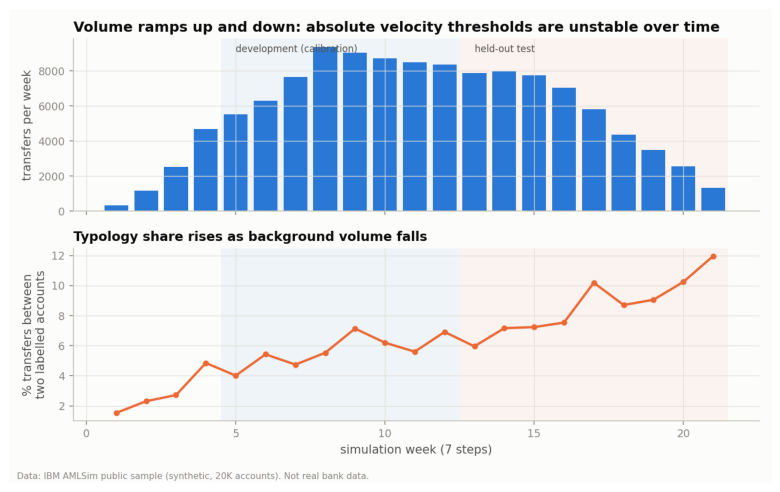

,week,transactions,value,proxy_typology_share,senders,receivers,complete_week
0,1,325,8.5995e+04,0.0154,320,318,True
1,2,1167,3.5015e+05,0.0231,1080,1047,True
2,3,2534,7.0427e+05,0.0272,2260,2067,True
3,4,4695,1.3310e+06,0.0486,3758,3250,True
4,5,5529,1.5585e+06,0.0402,4321,3950,True
5,6,6298,1.7553e+06,0.0543,5041,4522,True
6,7,7668,2.1257e+06,0.0475,6226,5308,True
7,8,9379,2.6138e+06,0.0553,7137,6137,True
8,9,9045,2.5067e+06,0.0714,6872,6151,True
9,10,8717,2.3999e+06,0.0621,6801,6149,True


In [2]:
show("fig01_weekly_activity")
T("weekly_activity")

**Q2. Are typology transfers larger than other transfers?**

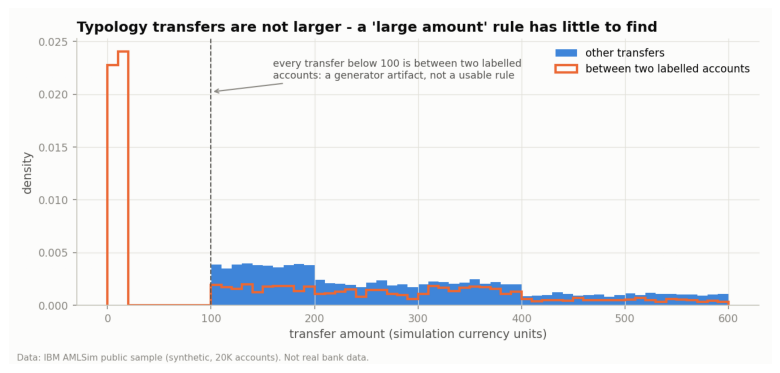

,proxy,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,0,112673.0,284.3254,137.5744,100.04,102.33,113.016,166.05,258.60,376.92,550.640,590.73,599.91
1,1,7885.0,158.7976,169.2958,2.51,2.74,3.110,10.73,116.61,296.89,497.856,572.26,599.71


In [3]:
show("fig02_amount_distribution")
T("amount_distribution_by_proxy_label")

**Q3. How concentrated is transfer value across accounts?**

Gini of account value: 0.363; top 1% share 0.074; top 10% share 0.283


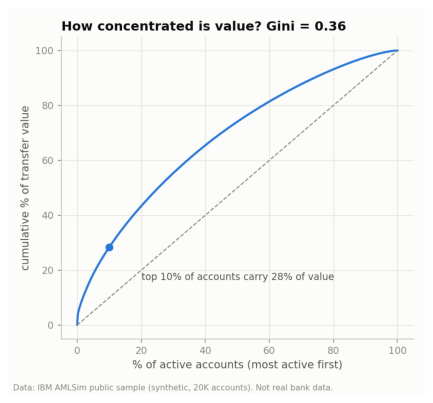

In [4]:
show("fig03_value_concentration", 6)
print(f"Gini of account value: {KM['gini_value']:.3f}; top 1% share {KM['top1pct_value_share']:.3f}; top 10% share {KM['top10pct_value_share']:.3f}")

**Q4. Which SQL-level patterns stand out (velocity, pass-through, concentration)?**

In [5]:
pd.read_csv(config.TABLES_DIR / "sql" / "q04_inflow_outflow_behaviour.csv")

,flow_profile,accounts,avg_transactions,avg_inflow,avg_outflow
0,net distributor,9520,11.1,1209.5,2343.7
1,net accumulator,8361,13.4,2250.3,949.1
2,pass-through (in ~ out),1925,12.0,1522.7,1527.0
3,one-directional,174,2.9,135.8,559.2


In [6]:
pd.read_csv(config.TABLES_DIR / "sql" / "q03_highest_velocity_accounts.csv").head(10)

,account_id,peak_week_tx,total_tx,active_weeks,tx_per_active_week,velocity_rank
0,9998,36,373,18,20.72,1
1,9999,36,371,19,19.53,1
2,19993,36,241,20,12.05,1
3,19998,36,360,17,21.18,1
4,19999,35,343,17,20.18,5
5,9984,32,207,17,12.18,6
6,9988,27,216,17,12.71,7
7,9987,25,233,18,12.94,8
8,9989,25,232,19,12.21,8
9,9990,25,223,17,13.12,8


In [7]:
pd.read_csv(config.TABLES_DIR / "sql" / "q06_sudden_activity_change.csv").head(10)

,account_id,week,tx,trailing_avg,spike_ratio
0,19999,8,16,1.00,16.00
1,5543,8,10,1.00,10.00
2,9668,7,9,1.00,9.00
3,8872,8,11,1.25,8.80
4,9989,4,13,1.50,8.67
5,19971,4,11,1.33,8.25
6,19640,11,16,2.00,8.00
7,7169,18,8,1.00,8.00
8,11773,14,8,1.00,8.00
9,11887,18,8,1.00,8.00


**Q5. Do value flows concentrate in a few relationships?**

In [8]:
pd.read_csv(config.TABLES_DIR / "sql" / "q07_highest_value_relationships.csv").head(10)

,src,dst,n,value,first_step,last_step,pct_of_all_value,cumulative_pct
0,4924,10453,6,686.56,81,92,0.0021,0.002
1,16888,1618,6,658.40,46,81,0.0020,0.004
2,15133,3046,6,642.43,55,71,0.0019,0.006
3,18920,15152,5,616.85,106,127,0.0019,0.008
4,1104,5398,6,615.50,48,103,0.0018,0.010
5,3125,4534,6,607.83,39,90,0.0018,0.011
6,16888,17197,3,606.49,130,135,0.0018,0.013
7,8917,8685,3,605.51,92,139,0.0018,0.015
8,14837,1173,1,599.91,74,74,0.0018,0.017
9,14837,4720,1,599.91,56,56,0.0018,0.019


**Not possible with this data:** time-of-day / day-of-week patterns (only a daily step index), transaction-type
behaviour (no type field), merchant or geographic analysis (no such fields).